Saving tinggi.xlsx to tinggi.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

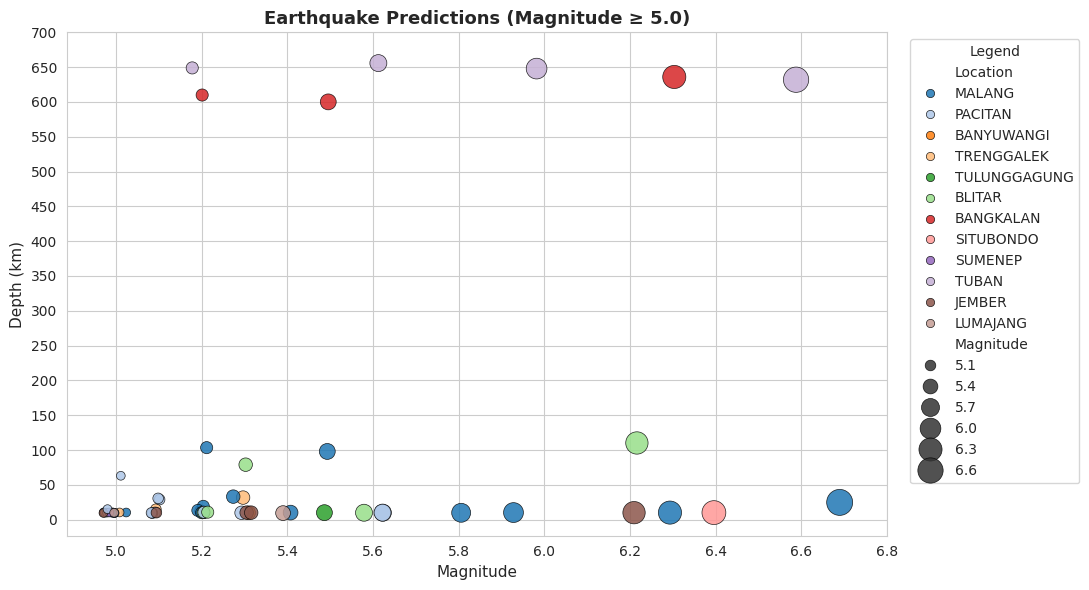

In [1]:
# Upload file XLSX
from google.colab import files
uploaded = files.upload()

# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Baca file XLSX
file_name = list(uploaded.keys())[0]
data = pd.read_excel(file_name)

# Rapikan nama kolom
data.columns = data.columns.str.strip()

# Filter: hanya Magnitude ≥ 5.0
data = data[data['Magnitude'] >= 5.0].copy()

# Tambahkan jitter untuk visualisasi
np.random.seed(42)
data['Magnitude_jitter'] = data['Magnitude'] + np.random.normal(0, 0.015, len(data))
data['Depth_jitter'] = data['Depth (km)'] + np.random.normal(0, 0.3, len(data))

# Custom color palette yang kontras (bukan pastel)
palette = sns.color_palette("tab10", n_colors=data['Location'].nunique())

# Plot
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=data,
    x='Magnitude_jitter',
    y='Depth_jitter',
    hue='Location',
    size='Magnitude',
    sizes=(40, 350),
    palette="tab20",
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

# Axis & grid
plt.xticks(np.arange(5.0, data['Magnitude'].max() + 0.3, 0.2))
plt.yticks(range(0, int(data['Depth (km)'].max()) + 50, 50))

# Label & layout
plt.title("Earthquake Predictions (Magnitude ≥ 5.0)", fontsize=13, weight='bold')
plt.xlabel("Magnitude", fontsize=11)
plt.ylabel("Depth (km)", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legend")
plt.tight_layout()

# Simpan TIFF resolusi tinggi
plt.savefig("bubble_earthquake_predictions_M5plus.tiff", dpi=600, format='tiff')

# Download otomatis
from google.colab import files
files.download("bubble_earthquake_predictions_M5plus.tiff")